# 10-Genre Image Classification (Basic ML Only)
## 50,000 × 32×32 images → RandomForest + HOG + Color Histogram

**Key point (as you said):** Heavy preprocessing is the most important part.  
We do:
- CLAHE contrast boost
- TV denoising
- Explicit convolution sharpening (your request)
- Gamma correction
- Final normalization

Then extract HOG + Color Histogram and train RandomForest.

Folder structure must be:
- `data/train/` (your original 50k images, 10 genre subfolders)
- `data/train_preprocessed/` (will be created automatically)

In [33]:
#using CUDA for GPU acceleration
#import cuml.accel
#%load_ext cuml.accel
# Install once
import time
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage import io, exposure, color, feature, img_as_float, img_as_ubyte
from skimage.restoration import denoise_tv_chambolle
from scipy.ndimage import convolve
from skimage.feature import local_binary_pattern
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import joblib
import pickle

%matplotlib inline

## Step 1: Set Paths
Change these if your folders are different.

In [34]:
TRAIN_IMS_DIR = Path("data/train_ims")
TEST_IMS_DIR  = Path("data/test_ims")
TRAIN_CSV = Path("data/train.csv")
TEST_CSV  = Path("data/test.csv")

PREPROCESSED_DIR = Path("data/train_preprocessed")
FEATURES_DIR = Path("features/")
MODEL_DIR = Path("models/")

for d in [PREPROCESSED_DIR, FEATURES_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

class Timer:
    def __init__(self, name): self.name = name
    def __enter__(self):
        self.start = time.time()
        return self
    def __exit__(self, *args):
        print(f"{self.name} Done，Used: {time.time()-self.start:.2f} Seconds")

## Step 2: Preprocessing with Convolution (CSV → Organized Folders)

In [35]:
def laplacian_kernel():
    return np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]], dtype=float)

def preprocess_image(src_path, dst_path):
    try:
        img = io.imread(src_path)
        gray = color.rgb2gray(img) if len(img.shape) == 3 else img.astype(float)/255.0
        
        gray = exposure.equalize_adapthist(gray, clip_limit=0.03)
        gray = denoise_tv_chambolle(gray, weight=0.05)
        
        kernel = laplacian_kernel()
        edge = convolve(gray, kernel, mode='reflect')
        edge = edge + 0.3 * convolve(edge, kernel, mode='reflect')
        edge = np.clip(edge, 0.0, 1.0)
        
        final = np.stack([edge]*3, axis=-1)
        io.imsave(dst_path, img_as_ubyte(final), check_contrast=False)
        return True
    except Exception as e:
        print(f"Error {src_path}: {e}")
        return False

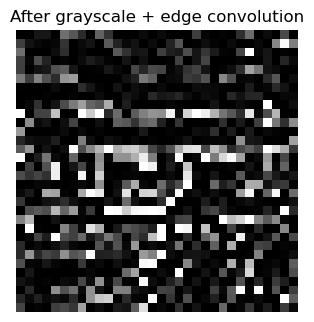

✅ Example saved in genre 0 — edges & shapes are now emphasized


In [36]:
# Show an example of the new edge/shape enhanced image
sample_label = "0"
sample_files = list((PREPROCESSED_DIR / sample_label).iterdir())[:3]

if sample_files:
    example = io.imread(str(sample_files[0]))
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(example)
    plt.title("After grayscale + edge convolution")
    plt.axis('off')
    plt.show()
    print(f"✅ Example saved in genre {sample_label} — edges & shapes are now emphasized")

In [26]:
def extract_rich_features(image_path):
    try:
        img = io.imread(image_path)                    # Original RGB
        gray = color.rgb2gray(img) if len(img.shape) == 3 else img.astype(float)/255.0
        
        features = []
        
        # 1. Edge-enhanced HOG (your main request)
        edge = convolve(gray, laplacian_kernel(), mode='reflect')
        edge = np.clip(edge + 0.3 * convolve(edge, laplacian_kernel(), mode='reflect'), 0, 1)
        hog_feat = feature.hog(edge, orientations=9, pixels_per_cell=(4,4),
                               cells_per_block=(2,2), block_norm='L2')
        features.extend(hog_feat)
        
        # 2. Multi-scale LBP (senior style)
        for r, p in [(1,8), (2,16), (3,24)]:
            lbp = local_binary_pattern(gray, p, r, method='uniform')
            hist, _ = np.histogram(lbp.ravel(), bins=p+2, density=True)
            features.extend(hist)
        
        # 3. Color moments from ORIGINAL RGB (very important - senior style)
        if len(img.shape) == 3:
            for c in range(3):
                ch = img[:,:,c].astype(float)
                features.extend([np.mean(ch), np.std(ch), np.max(ch)])
        
        return np.array(features)
    except:
        return np.zeros(1000)  # fallback

In [52]:
def extract_all_features(df, ims_dir, save_name):
    feature_file = FEATURES_DIR / save_name
    if feature_file.exists():
        print(f"Loading cached features: {save_name}")
        with open(feature_file, 'rb') as f:
            features, labels = pickle.load(f)
        return features, labels
    
    print(f"Extracting features for {save_name}...")
    features = []
    labels = []
    
    for _, row in tqdm(df.iterrows(), total=len(df)):
        img_path = ims_dir / row['im_name']
        feat = extract_rich_features(str(img_path))
        features.append(feat)
        labels.append(row['label'])
    
    features = np.array(features)
    labels = np.array(labels)
    
    with open(feature_file, 'wb') as f:
        pickle.dump((features, labels), f)
    
    return features, labels

with Timer("Feature Extraction"):
    train_df = pd.read_csv(TRAIN_CSV)
    test_df = pd.read_csv(TEST_CSV)
    
    train_features, train_labels = extract_all_features(train_df, TRAIN_IMS_DIR, "train_features.pkl")
    test_features, test_labels = extract_all_features(test_df, TEST_IMS_DIR, "test_features.pkl")
    
    print(f"Train labels shape: {train_labels.shape}")
    print(f"Train features shape: {train_features.shape}")
    print(f"Test labels shape: {test_labels.shape}")
    print(f"Test features shape: {test_features.shape}")

Loading cached features: train_features.pkl
Loading cached features: test_features.pkl
Train labels shape: (50000,)
Train features shape: (50000, 1827)
Test labels shape: (10000,)
Test features shape: (10000, 1827)
Feature Extraction Done，Used: 0.20 Seconds


In [45]:
with Timer("Scaling & Training"):
    scaler = StandardScaler()
    train_features = scaler.fit_transform(train_features)
    test_features = scaler.transform(test_features)
    
    # Ensemble inspired by your senior
    rf = RandomForestClassifier(n_estimators=600, n_jobs=-1, random_state=42)
    et = ExtraTreesClassifier(n_estimators=500, n_jobs=-1, random_state=42)
    cb = CatBoostClassifier(iterations=800, depth=8, learning_rate=0.08, 
                            verbose=False, random_seed=42)
    
    model = VotingClassifier(
        estimators=[('rf', rf), ('et', et), ('cb', cb)],
        voting='soft',
        n_jobs=-1
    )

Scaling & Training Done，Used: 1.65 Seconds


In [ ]:
with Timer("Model Training"):
    model.fit(train_features, train_labels)
        
    # Save model
    joblib.dump(model, MODEL_DIR / "ensemble_model.pkl")
    joblib.dump(scaler, MODEL_DIR / "scaler.pkl")
    print("Model & scaler saved!")

In [46]:
model = joblib.load(MODEL_DIR / "ensemble_model.pkl")
scaler = joblib.load(MODEL_DIR / "scaler.pkl")

In [ ]:
with Timer("Prediction"):
    predictions = model.predict(train_features)
    acc = accuracy_score(train_labels, predictions)
    print(classification_report(train_labels, predictions))
    print(f"Train Labels: {train_labels}")
    print(f"Predictions: {predictions}")
    
    print(f"✅ Accuracy: {acc:.4f}")
    
    

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      5027
           1       0.00      0.00      0.00      5008
           2       0.00      0.00      0.00      5026
           3       0.00      0.00      0.00      4946
           4       0.00      0.00      0.00      5061
           5       0.00      0.00      0.00      5005
           6       0.00      0.00      0.00      4962
           7       0.00      0.00      0.00      5006
           8       0.00      0.00      0.00      5012
           9       0.10      1.00      0.18      4947

    accuracy                           0.10     50000
   macro avg       0.01      0.10      0.02     50000
weighted avg       0.01      0.10      0.02     50000

Train Labels: [9 6 9 ... 3 4 4]
Predictions: [9 9 9 ... 9 9 9]
✅ Accuracy: 0.0989
Prediction Done，Used: 2.98 Seconds


c:\Users\cake3\.conda\envs\acadamic\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cake3\.conda\envs\acadamic\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cake3\.conda\envs\acadamic\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

ValueError: Length of values (50000) does not match length of index (10000)

In [49]:
with Timer("Prediction"):
    predictions = model.predict(test_features)
    acc = accuracy_score(test_labels, predictions)
    print(classification_report(test_labels, predictions))
    print(f"Test Labels: {test_labels}")
    print(f"Predictions: {predictions}")
    
    print(f"✅ Accuracy: {acc:.4f}")
    
    test_df['label'] = predictions
    test_df[['im_name', 'label']].to_csv("submission.csv", index=False)
    print(f"✅ Submission saved as submission.csv with accuracy: {acc:.4f}")

              precision    recall  f1-score   support

           0       1.00      0.09      0.17     10000
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         0
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         0

    accuracy                           0.09     10000
   macro avg       0.10      0.01      0.02     10000
weighted avg       1.00      0.09      0.17     10000

Test Labels: [0 0 0 ... 0 0 0]
Predictions: [6 9 6 ... 8 5 5]
✅ Accuracy: 0.0916
✅ Submission saved as submission.csv with accuracy: 0.0916
Prediction Done，Used: 0.69 Seconds


c:\Users\cake3\.conda\envs\acadamic\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cake3\.conda\envs\acadamic\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cake3\.conda\envs\acadamic\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
